In [ ]:
!pip3 install requests

In [ ]:
%%writefile axelar_downloader.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
AxelarScan GMP downloader: search, single tx, and batch mode (150-per-CSV chunks).
- Respects API offset cap (150) by shifting a time window backwards in batch mode.
- Exports JSON and/or flattened CSV suitable for Excel/Pandas.
"""

import argparse
import csv
import json
import sys
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional

try:
    import requests  # type: ignore[import-not-found]
    HTTPError = requests.HTTPError
    RequestException = requests.RequestException
except ModuleNotFoundError:
    requests = None
    from urllib import error as urllib_error
    from urllib import parse as urllib_parse
    from urllib import request as urllib_request

    HTTPError = urllib_error.HTTPError
    RequestException = urllib_error.URLError

# ---------------------------------------------------------------------------

BASE_URL = "https://api.axelarscan.io/gmp"
DEFAULT_PAGE_SIZE = 25
MAX_PAGE_SIZE = 25
MAX_FROM_OFFSET = 2000  # API cap for 'from' (offset)

class AxelarscanError(RuntimeError):
    """Raised when the Axelarscan API reports an error condition."""

# ---------------------------------------------------------------------------

def call_axelarscan(params: Dict[str, Any], *, retries: int = 3, backoff: float = 1.5) -> Dict[str, Any]:
    """
    Call the Axelarscan GMP endpoint and return the parsed JSON payload.

    Parameters
    ----------
    params: dict
        Query parameters to send to the API. The `method` key will be injected automatically.
    retries: int
        Number of retry attempts on transient HTTP errors.
    backoff: float
        Multiplier (in seconds) between retry attempts.
    """
    params = {"method": "searchGMP", **params}
    attempt = 0
    while True:
        attempt += 1
        try:
            if requests is not None:
                response = requests.get(BASE_URL, params=params, timeout=30)
                response.raise_for_status()
                payload: Dict[str, Any] = response.json()
            else:
                url = f"{BASE_URL}?{urllib_parse.urlencode(params)}"
                with urllib_request.urlopen(url, timeout=30) as response:
                    payload = json.loads(response.read().decode("utf-8"))
        except HTTPError:
            if attempt > retries:
                raise
            sleep_for = backoff ** (attempt - 1)
            time.sleep(sleep_for)
            continue
        except RequestException:
            if attempt > retries:
                raise
            sleep_for = backoff ** (attempt - 1)
            time.sleep(sleep_for)
            continue
        if payload.get("error"):
            raise AxelarscanError(json.dumps(payload, ensure_ascii=False))
        return payload

def iterate_transactions(
    *,
    filters: Optional[Dict[str, Any]] = None,
    page_size: int = DEFAULT_PAGE_SIZE,
    limit: Optional[int] = None,
) -> Iterable[Dict[str, Any]]:
    """Yield GMP transactions using the `searchGMP` method with automatic pagination."""
    if page_size <= 0:
        raise ValueError("page_size must be positive")
    if page_size > MAX_PAGE_SIZE:
        raise ValueError(f"page_size cannot exceed {MAX_PAGE_SIZE} per API limits")

    filters = {**(filters or {})}
    offset = int(filters.pop("from", 0))
    fetched = 0
    effective_limit = min(limit, MAX_FROM_OFFSET) if limit is not None else MAX_FROM_OFFSET
    warn_on_truncation = limit is None or (limit is not None and limit > MAX_FROM_OFFSET)

    while True:
        if offset >= MAX_FROM_OFFSET:
            if warn_on_truncation:
                print(
                    f"Reached API offset cap of {MAX_FROM_OFFSET}. Narrow the window with --from-time/--to-time to retrieve more records.",
                    file=sys.stderr,
                )
            break

        params = {"from": offset, "size": page_size, **filters}
        payload = call_axelarscan(params)
        data: List[Dict[str, Any]] = payload.get("data", [])
        total = payload.get("total")

        if not data:
            break

        for tx in data:
            yield tx
            fetched += 1
            if effective_limit is not None and fetched >= effective_limit:
                if warn_on_truncation:
                    print(
                        f"Stopped after {fetched} records due to the API offset cap ({MAX_FROM_OFFSET}). Narrow the window with --from-time/--to-time for additional results.",
                        file=sys.stderr,
                    )
                return

        offset += len(data)
        if total is not None and offset >= int(total):
            break

        # Backend enforces a modest rate-limit; sleep a bit to be friendly.
        time.sleep(0.25)

def fetch_transaction(tx_hash: str) -> Optional[Dict[str, Any]]:
    """Retrieve a single transaction (if present) by its message/tx hash."""
    payload = call_axelarscan({"txHash": tx_hash, "size": 1})
    records = payload.get("data", [])
    if records:
        return records[0]
    return None

# ---------------------------------------------------------------------------

def write_json(data: List[Dict[str, Any]], path: Path) -> None:
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False))

def write_csv(data: List[Dict[str, Any]], path: Path) -> None:
    if not data:
        path.write_text("")
        return

    # Flatten a few frequently used top-level fields. Nested data will be stored as JSON strings.
    fieldnames = [
        "message_id",
        "status",
        "simplified_status",
        "symbol",
        "amount",
        "value",
        "source_chain",
        "destination_chain",
        "call.chain",
        "call.transactionHash",
        "created_at.ms",
    ]

    # Build rows.
    rows: List[Dict[str, Any]] = []
    for tx in data:
        row: Dict[str, Any] = {}
        row["message_id"] = tx.get("message_id")
        row["status"] = tx.get("status")
        row["simplified_status"] = tx.get("simplified_status")
        row["symbol"] = tx.get("symbol")
        row["amount"] = tx.get("amount")
        row["value"] = tx.get("value")
        row["source_chain"] = tx.get("source_chain") or tx.get("call", {}).get("chain")
        row["destination_chain"] = tx.get("destination_chain") or tx.get("call", {}).get("destination_chain")
        row["call.chain"] = tx.get("call", {}).get("chain")
        row["call.transactionHash"] = tx.get("call", {}).get("transactionHash")
        row["created_at.ms"] = tx.get("created_at", {}).get("ms")

        # Add any remaining keys (flattened JSON strings so nothing is dropped).
        for key, value in tx.items():
            if key in row:
                continue
            row[key] = json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else value

        rows.append(row)

    # Ensure all columns are represented.
    all_columns = list(dict.fromkeys(fieldnames + [key for row in rows for key in row.keys()]))
    with path.open("w", newline="", encoding="utf-8") as fh:
        writer = csv.DictWriter(fh, fieldnames=all_columns)
        writer.writeheader()
        writer.writerows(rows)

# ---------------------------------------------------------------------------
# CLI args
# ---------------------------------------------------------------------------

def parse_filters(args: argparse.Namespace) -> Dict[str, Any]:
    filters: Dict[str, Any] = {}
    if args.event:
        filters["event"] = args.event
    if args.source_chain:
        filters["sourceChain"] = args.source_chain
    if args.destination_chain:
        filters["destinationChain"] = args.destination_chain
    if args.status:
        filters["status"] = args.status
    if args.sender:
        filters["senderAddress"] = args.sender
    if args.contract:
        filters["contractAddress"] = args.contract
    if args.from_time:
        filters["fromTime"] = args.from_time
    if args.to_time:
        filters["toTime"] = args.to_time
    if args.sort:
        filters["sort"] = args.sort
    return filters

def add_search_arguments(target: argparse._ActionsContainer) -> None:
    target.add_argument("--page-size", type=int, default=DEFAULT_PAGE_SIZE, help="Items per request (max: 25, default: 25)")
    target.add_argument("--limit", type=int, help="Stop after N records (omit for full dataset).")
    target.add_argument("--event", help="Filter by event type, e.g. ContractCallWithToken")
    target.add_argument("--source-chain", help="Filter by source chain name (case sensitive)")
    target.add_argument("--destination-chain", help="Filter by destination chain name")
    target.add_argument("--status", help="Filter by status (executed, failed, etc.)")
    target.add_argument("--sender", help="Filter by sender address")
    target.add_argument("--contract", help="Filter by contract address")
    target.add_argument("--from-time", type=int, help="Unix timestamp (seconds) for start of window")
    target.add_argument("--to-time", type=int, help="Unix timestamp (seconds) for end of window")
    target.add_argument("--sort", help="Sort expression supported by the API (e.g. '-created_at')")
    target.add_argument("--out-json", type=Path, help="Write the complete response list to JSON")
    target.add_argument("--out-csv", type=Path, help="Write a flattened CSV alongside the JSON output")

def build_arg_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description="Download Axelar GMP transactions via the public API.")

    parser.set_defaults(
        command="search",
        page_size=DEFAULT_PAGE_SIZE,
        limit=None,
        event=None,
        source_chain=None,
        destination_chain=None,
        status=None,
        sender=None,
        contract=None,
        from_time=None,
        to_time=None,
        sort=None,
        out_json=None,
        out_csv=None,
    )

    add_search_arguments(parser)
    subparsers = parser.add_subparsers(dest="command", required=False)

    # `search` command (default)
    search_parser = subparsers.add_parser("search", help="Iterate through transactions with optional filters.")
    search_parser.set_defaults(command="search")
    add_search_arguments(search_parser)

    # `tx` command to fetch a single transaction
    tx_parser = subparsers.add_parser("tx", help="Fetch the most recent record for a transaction hash / message id.")
    tx_parser.add_argument("tx_hash", help="Transaction hash or message id, e.g. 0x...-16")
    tx_parser.add_argument("--out-json", type=Path, help="Write the response to JSON")

    # `batch` command – download in 150-row CSV chunks into a directory
    batch_parser = subparsers.add_parser("batch", help="Download transactions in 150-row CSV batches into a directory.")
    batch_parser.set_defaults(command="batch")
    add_search_arguments(batch_parser)
    batch_parser.add_argument("--out-dir", type=Path, required=True, help="Output directory for CSV batches.")
    batch_parser.add_argument("--target-total", type=int, default=5000, help="Total rows to collect (default: 5000).")
    batch_parser.add_argument("--batch-size", type=int, default=MAX_FROM_OFFSET,
                              help=f"Rows per CSV (max {MAX_FROM_OFFSET}, default: {MAX_FROM_OFFSET}).")
    batch_parser.add_argument("--start-to-time", type=int, help="Unix seconds to start from (default: now).")
    batch_parser.add_argument("--hard-from-time", type=int, help="Stop when the window goes older than this (Unix seconds).")

    return parser

# ---------------------------------------------------------------------------
# Batch helpers
# ---------------------------------------------------------------------------

def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def min_created_at_seconds(batch: List[Dict[str, Any]]) -> Optional[int]:
    """
    Najdi nejmenší created_at (ms) v dávce a vrať v sekundách.
    Pokud není k dispozici, vrať None.
    """
    ms_vals: List[int] = []
    for tx in batch:
        ms = None
        if isinstance(tx.get("created_at"), dict):
            ms = tx["created_at"].get("ms")
        if ms is None and "created_at.ms" in tx:
            try:
                ms = int(tx["created_at.ms"])
            except Exception:
                pass
        if isinstance(ms, (int, float)):
            ms_vals.append(int(ms))
    if not ms_vals:
        return None
    return max(0, min(ms_vals) // 1000)

def write_csv_batch(data: List[Dict[str, Any]], out_path: Path) -> None:
    write_csv(data, out_path)

def download_in_batches(
    out_dir: Path,
    *,
    base_filters: Optional[Dict[str, Any]] = None,
    batch_size: int = MAX_FROM_OFFSET,   # 150
    target_total: int = 5000,
    start_to_time: Optional[int] = None, # unix seconds; default "now"
    hard_from_time: Optional[int] = None # stop when older than this
) -> int:
    """
    Download transactions in batches so that each CSV has <= 150 rows (API cap).
    Walk backwards in time by setting `toTime` to (oldest_in_batch - 1s) each loop.
    Returns total downloaded rows across all batches.
    """
    ensure_dir(out_dir)
    filters = dict(base_filters or {})
    # enforce sorting by newest first; API expects '-created_at' for descending
    filters["sort"] = filters.get("sort") or "-created_at"

    # starting point (toTime)
    if start_to_time is None:
        start_to_time = int(time.time())
    current_to = start_to_time

    total = 0
    part = 0
    page_size = min(DEFAULT_PAGE_SIZE, MAX_PAGE_SIZE)  # 25
    per_batch_limit = min(max(1, batch_size), MAX_FROM_OFFSET)

    while total < target_total:
        window_filters = dict(filters)
        window_filters["toTime"] = current_to
        if hard_from_time is not None:
            window_filters["fromTime"] = hard_from_time

        batch = list(
            iterate_transactions(
                filters=window_filters,
                page_size=page_size,
                limit=per_batch_limit,
            )
        )
        if not batch:
            # no data in this window -> stop
            break

        part += 1
        out_csv = out_dir / f"part_{part:04d}.csv"
        write_csv_batch(batch, out_csv)
        print(f"[batch {part:04d}] wrote {len(batch)} rows -> {out_csv}", file=sys.stderr)

        total += len(batch)
        if total >= target_total:
            break

        # compute next window's toTime as (oldest_in_batch - 1s)
        oldest_s = min_created_at_seconds(batch)
        if oldest_s is None:
            # cannot reliably continue without timestamps
            break
        next_to = oldest_s - 1

        if hard_from_time is not None and next_to < hard_from_time:
            break

        current_to = next_to

        time.sleep(0.25)  # be nice to the backend

    return total

# ---------------------------------------------------------------------------
# Commands
# ---------------------------------------------------------------------------

def cmd_search(args: argparse.Namespace) -> int:
    filters = parse_filters(args)
    data = list(
        iterate_transactions(
            filters=filters,
            page_size=args.page_size,
            limit=args.limit,
        )
    )

    if args.out_json:
        write_json(data, args.out_json)
        print(f"Wrote {len(data)} records to {args.out_json}")

    if args.out_csv:
        write_csv(data, args.out_csv)
        print(f"Wrote flattened CSV to {args.out_csv}")

    if not args.out_json and not args.out_csv:
        json.dump(data, sys.stdout, indent=2, ensure_ascii=False)
        sys.stdout.write("\n")

    return 0

def cmd_tx(args: argparse.Namespace) -> int:
    record = fetch_transaction(args.tx_hash)
    if record is None:
        print("No transaction found", file=sys.stderr)
        return 1

    if args.out_json:
        write_json([record], args.out_json)
        print(f"Wrote transaction to {args.out_json}")
    else:
        json.dump(record, sys.stdout, indent=2, ensure_ascii=False)
        sys.stdout.write("\n")

    return 0

def cmd_batch(args: argparse.Namespace) -> int:
    # take only filter args that make sense; sort enforced within download_in_batches
    filters = parse_filters(args)
    total = download_in_batches(
        args.out_dir,
        base_filters=filters,
        batch_size=args.batch_size,
        target_total=args.target_total,
        start_to_time=args.start_to_time,
        hard_from_time=args.hard_from_time,
    )
    print(f"Downloaded total {total} rows into directory {args.out_dir}", file=sys.stderr)
    return 0

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main(argv: Optional[List[str]] = None) -> int:
    parser = build_arg_parser()
    args = parser.parse_args(argv)
    command = args.command or "search"

    try:
        if command == "search":
            return cmd_search(args)
        if command == "tx":
            return cmd_tx(args)
        if command == "batch":
            return cmd_batch(args)
    except AxelarscanError as exc:
        print(f"Axelarscan API reported an error: {exc}", file=sys.stderr)
        return 1
    except RequestException as exc:
        print(f"Network error: {exc}", file=sys.stderr)
        return 1

    parser.print_help()
    return 1

if __name__ == "__main__":  # pragma: no cover
    sys.exit(main())

Overwriting axelar_downloader.py


In [ ]:
# Hodnota pro --to-time (nejstarší záznam z první dávky mínus 1 sekunda)
NEXT_TO_TIME = 1762963249 - 1
print(f"Používám --to-time {NEXT_TO_TIME} pro stažení starších dat.")

# Krok 2a: Vytvoříme adresář pro dávky
!mkdir -p axelarscan_data

# Krok 2b: Přesuneme první úspěšně stažený soubor (simulovaná dávka 1)
# Poznámka: Používáme -f pro vynucené přesunutí, i když by cílový soubor existoval
!mv -f axelarscan_part_1.csv axelarscan_data/part_0001.csv
print("První dávka je připravena v axelarscan_data/part_0001.csv")

# Krok 2c: Stáhneme druhou dávku dat (part_0002.csv)
# - --limit 150: Omezíme na maximální API offset
# - --out-csv axelarscan_data/part_0002.csv: Uložíme do nového souboru v adresáři
# - --to-time {NEXT_TO_TIME}: Zajistíme, že data budou starší než ta z první dávky
print("\nStahuji druhou dávku (part_0002.csv)...")
!python axelar_downloader.py search --limit 2000 --out-csv axelarscan_data/part_0002.csv --to-time {NEXT_TO_TIME}

# Krok 2d: Zobrazení stažených řádků
print("\nKontrola souborů:")
!wc -l axelarscan_data/part_*.csv

Používám --to-time 1762963248 pro stažení starších dat.
mv: cannot stat 'axelarscan_part_1.csv': No such file or directory
První dávka je připravena v axelarscan_data/part_0001.csv

Stahuji druhou dávku (part_0002.csv)...
Wrote flattened CSV to axelarscan_data/part_0002.csv

Kontrola souborů:
2001 axelarscan_data/part_0002.csv


In [ ]:
import pandas as pd
from pathlib import Path
import os
import subprocess

# --- KONFIGURACE CÍLŮ A OMEZENÍ ---
MAX_LIMIT = 2000
TARGET_TRANSACTIONS = 2000
MAX_BATCHES = (TARGET_TRANSACTIONS // MAX_LIMIT) + 1
DATA_DIR = Path("axelarscan_data")
FALLBACK_TIMESTAMP = 1762963249 # Konzervativní čas z part_0001
# ----------------------------------

def find_oldest_valid_timestamp(df, fallback_time):
    """Najde nejstarší NE-NaN časovou značku v DataFrame."""
    # Procházíme řádky od konce (od nejstarších)
    for index, row in df.iloc[::-1].iterrows():
        timestamp_ms = row.get('created_at.ms')

        # Kontrola, zda je hodnota číslo a není NaN
        if pd.notna(timestamp_ms):
            try:
                # Převod na int a sekundy
                return int(timestamp_ms) // 1000
            except ValueError:
                # Pokračovat, pokud nelze převést (např. prázdný řetězec)
                continue

    # Pokud nebyla nalezena žádná platná časová značka, vracíme fallback čas
    print(f"Upozornění: V dávce nebyla nalezena žádná platná časová značka. Používám fallback čas {fallback_time}.")
    return fallback_time

# --- Inicializace ---
DATA_DIR.mkdir(parents=True, exist_ok=True)
csv_files = sorted(DATA_DIR.glob("part_*.csv"))

LAST_TIMESTAMP = FALLBACK_TIMESTAMP
BATCH_COUNT = 1

if csv_files:
    last_file = csv_files[-1]
    last_batch_num = int(last_file.stem.split('_')[-1])
    BATCH_COUNT = last_batch_num + 1

    try:
        df_last_batch = pd.read_csv(last_file)
        # Použití nové robustní funkce
        LAST_TIMESTAMP = find_oldest_valid_timestamp(df_last_batch, FALLBACK_TIMESTAMP)

    except Exception as e:
        print(f"Chyba při načítání poslední dávky {last_file}: {e}. Používám konzervativní čas.")
        LAST_TIMESTAMP = FALLBACK_TIMESTAMP

# Odhadovaný počet stažených transakcí (pro tisk)
total_downloaded_count = len(csv_files) * MAX_LIMIT
print(f"Nalezeno {len(csv_files)} existujících dávek. Budeme pokračovat s Dávkou {BATCH_COUNT}.")
print(f"Nová, bezpečná startovní časová značka: {LAST_TIMESTAMP}. Budeme stahovat transakce starší než {LAST_TIMESTAMP - 1} s.")
print("-" * 60)

# --- 2. Automatická smyčka pro stahování ---
while BATCH_COUNT <= MAX_BATCHES:
    NEXT_TO_TIME = LAST_TIMESTAMP - 1
    OUTPUT_FILE = DATA_DIR / f"part_{BATCH_COUNT:04d}.csv"

    print(f"Dávka {BATCH_COUNT}/{MAX_BATCHES}: Stahuji do {OUTPUT_FILE.name} s --to-time {NEXT_TO_TIME}...")

    # Spuštění skriptu axelar_downloader.py
    try:
        command = [
            "python", "axelar_downloader.py", "search",
            "--limit", str(MAX_LIMIT),
            "--out-csv", str(OUTPUT_FILE),
            "--to-time", str(NEXT_TO_TIME)
        ]
        # Potlačujeme výstup z shellu, ale zachytáváme chyby
        subprocess.run(command, check=True, capture_output=True, text=True)

    except subprocess.CalledProcessError as e:
        print(f"Chyba při spouštění skriptu pro Dávku {BATCH_COUNT}. Ukončuji stahování. Chyba: {e.stderr}")
        break
    except FileNotFoundError:
        print("Chyba: Skript 'axelar_downloader.py' nebyl nalezen. Ukončuji stahování.")
        break

    # Zpracování a kontrola stažené dávky
    try:
        df_new_batch = pd.read_csv(OUTPUT_FILE)
    except Exception as e:
        print(f"Chyba při načítání souboru {OUTPUT_FILE}: {e}. Ukončuji stahování.")
        break

    current_batch_size = len(df_new_batch)

    # Kontrola, zda jsme narazili na konec dat
    if current_batch_size == 0:
        print(f"\n✅ Dávka {BATCH_COUNT} je prázdná. **Dosáhli jsme konce dat.**")
        # Odebrání prázdného souboru pro čistotu
        os.remove(OUTPUT_FILE)
        break
    elif current_batch_size < MAX_LIMIT:
        print(f"\n✅ Dávka {BATCH_COUNT} obsahuje pouze {current_batch_size} řádků. **Dosáhli jsme konce dat.**")
        total_downloaded_count += current_batch_size
        break

    # Aktualizace časové značky pro další iteraci
    # Používáme vylepšenou funkci pro získání bezpečného timestampu z nově stažené dávky
    LAST_TIMESTAMP = find_oldest_valid_timestamp(df_new_batch, LAST_TIMESTAMP)
    total_downloaded_count += current_batch_size

    print(f"   -> Úspěšně staženo {current_batch_size} řádků. Celkem staženo: cca {total_downloaded_count} transakcí.")
    print(f"   -> Nová --to-time pro Dávku {BATCH_COUNT + 1} bude: {LAST_TIMESTAMP - 1} s.")

    BATCH_COUNT += 1

print("-" * 60)
print(f"Automatické stahování dokončeno. Celkem bylo staženo {BATCH_COUNT - 1} dávek.")

# --- 3. Finální kontrola souborů ---
print("\nFinální kontrola souborů (počet řádků):")
!wc -l {DATA_DIR}/part_*.csv

Upozornění: V dávce nebyla nalezena žádná platná časová značka. Používám fallback čas 1762963249.
Nalezeno 1 existujících dávek. Budeme pokračovat s Dávkou 3.
Nová, bezpečná startovní časová značka: 1762963249. Budeme stahovat transakce starší než 1762963248 s.
------------------------------------------------------------
------------------------------------------------------------
Automatické stahování dokončeno. Celkem bylo staženo 2 dávek.

Finální kontrola souborů (počet řádků):
2001 axelarscan_data/part_0002.csv


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("axelarscan_data")

# Získání seznamu všech CSV souborů
csv_files = sorted(DATA_DIR.glob("part_*.csv"))

# Načtení všech CSV souborů do seznamu DataFrame
dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except Exception as e:
        print(f"Chyba při načítání souboru {file}: {e}")

# Spojení všech DataFrame do jednoho
if dfs:
    all_transactions_df = pd.concat(dfs, ignore_index=True)
    # Počet unikátních transakcí na základě 'message_id'
    unique_transactions_count = all_transactions_df['message_id'].nunique()
    print(f"Celkový počet unikátních transakcí (podle message_id) je: {unique_transactions_count}")
else:
    print("Nebyly nalezeny žádné CSV soubory ke zpracování v adresáři axelarscan_data.")

Celkový počet unikátních transakcí (podle message_id) je: 2000


In [ ]:
import shutil
from pathlib import Path


# Název adresáře, který chceme zkomprimovat
source_dir = Path("axelarscan_data")
# Název výstupního ZIP souboru
output_filename = 'axelarscan_data'


print(f"Komprimuji adresář '{source_dir}' do souboru '{output_filename}.zip'...")


# Vytvoření ZIP archivu
try:
   # shutil.make_archive automaticky vytvoří axelarscan_data.zip
   shutil.make_archive(
       base_name=output_filename,
       format='zip',
       root_dir='.', # Prohledávat aktuální adresář
       base_dir=source_dir
   )
   print("\n✅ Komprese dokončena.")
   print(f"Soubor '{output_filename}.zip' je vytvořen a je připraven ke stažení (hledejte jej v levém panelu souborů).")
except Exception as e:
   print(f"Chyba při komprimaci: {e}")


Komprimuji adresář 'axelarscan_data' do souboru 'axelarscan_data.zip'...

✅ Komprese dokončena.
Soubor 'axelarscan_data.zip' je vytvořen a je připraven ke stažení (hledejte jej v levém panelu souborů).


In [ ]:
# === Axelar – globální KPI (success rate, E2E, náklady) ===
# Vstup:  axelarscan_data/*.csv
# Výstup:
#   - axelar_processed_out/axelar_clean.csv   (event-level)
#   - axelar_processed_out/axelar_per_tx.csv  (1 řádek = 1 message_id)
#   - axelar_processed_out/axelar_kpi_summary.csv (KPI z per-tx)


import os, glob, json
from typing import Any, Iterable, Optional
import numpy as np
import pandas as pd


# ---------- cesty / konstanty ----------
INPUT_GLOB   = "axelarscan_data/*.csv"
OUT_DIR      = "axelar_processed_out"
OUT_CLEAN    = f"{OUT_DIR}/axelar_clean.csv"
OUT_PER_TX   = f"{OUT_DIR}/axelar_per_tx.csv"
OUT_KPI_CSV  = f"{OUT_DIR}/axelar_kpi_summary.csv"


E2E_PRIORITY = [
   "call_express_executed",   # nejpřesnější – express
   "approved_executed",       # standard schválené → vykonané
   "call_approved",           # fallback bez execute
   "call_confirm",            # fallback bez approve
   "total"                    # poslední možnost – celkový čas
]


JSON_CANDIDATES = [
   "call","fees","gas_paid","price","confirm","interchain_transfer",
   "interchain_transfers","time_spent","destination_express_fee","source_express_fee",
   "destination_native_token","source_token","destination_token","ethereum_token",
   "axelar_token","receipt","execute"
]


# ---------- helpers ----------
def is_json_like(x: str) -> bool:
   if not isinstance(x, str):
       return False
   s = x.strip()
   return (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]"))


def parse_maybe_json(x: Any) -> Any:
   if isinstance(x, (dict, list)):
       return x
   if is_json_like(x):
       try:
           return json.loads(x)
       except Exception:
           return x
   return x


def dict_get(d: Any, path: Iterable[str], default=None):
   cur = d
   for p in path:
       if not isinstance(cur, dict) or p not in cur:
           return default
       cur = cur[p]
   return cur


def to_float(x) -> Optional[float]:
   try:
       if x is None or (isinstance(x, float) and np.isnan(x)):
           return None
       return float(x)
   except Exception:
       return None


def extract_e2e_latency(ts: Any) -> Optional[int]:
   if not isinstance(ts, dict):
       return None
   for k in E2E_PRIORITY:
       v = ts.get(k)
       if isinstance(v, (int, float)) and v >= 0:
           return int(v)
   return None


def convert_natural_to_usd(natural: Any, token_obj: Any) -> float:
   amt = to_float(natural)
   if amt is None:
       return 0.0
   price = dict_get(token_obj, ["token_price", "usd"], 0.0) or 0.0
   return float(amt) * float(price)


def extract_l1_fee_usd(row: pd.Series) -> float:
   # OP/Base L1 fee (wei) × dest native token price (USD) / 1e18
   wei = None
   for col in ["receipt", "execute", "call"]:
       obj = row.get(col)
       v = dict_get(obj, ["l1Fee"]) or dict_get(obj, ["receipt", "l1Fee"])
       if v is not None:
           try:
               wei = int(v)
               break
           except Exception:
               try:
                   wei = int(float(v))
                   break
               except Exception:
                   pass
   if not wei:
       return 0.0


   price = 0.0
   for col in ["destination_native_token", "destination_token", "ethereum_token", "axelar_token"]:
       p = dict_get(row.get(col), ["token_price", "usd"])
       if p:
           price = float(p)
           break


   return (wei / 1e18) * price if price > 0 else 0.0


def ensure_json_columns(df: pd.DataFrame, cols) -> pd.DataFrame:
   for c in cols:
       if c in df.columns:
           df[c] = df[c].apply(parse_maybe_json)
   return df


def read_all_csv(pattern: str) -> pd.DataFrame:
   files = sorted(glob.glob(pattern))
   if not files:
       raise FileNotFoundError(f"Žádné soubory pro glob: {pattern}")
   return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


# agregace statusu na úroveň transakce
def aggregate_status(values: pd.Series) -> str:
   vals = values.astype(str).str.lower().tolist()
   # pokud kdekoliv vidím fail/error → failed
   if any(any(bad in v for bad in ["fail", "error", "revert", "timeout"]) for v in vals):
       return "failed"
   # jinak pokud kdekoliv vidím executed/success → received
   if any(any(ok in v for ok in ["executed", "express executed", "received", "completed", "success"]) for v in vals):
       return "received"
   # jinak pending
   return "pending"


# ---------- transform ----------
def make_clean(df: pd.DataFrame) -> pd.DataFrame:
   df = ensure_json_columns(df, JSON_CANDIDATES)


   # E2E (s) z time_spent
   df["e2e_sec"] = df.get("time_spent", pd.Series([None] * len(df))).apply(extract_e2e_latency)


   # Base fee USD
   def _base_fee_usd(fees):
       if isinstance(fees, dict):
           bf = dict_get(fees, ["base_fee_usd"])
           if bf is not None:
               return to_float(bf) or 0.0
           s = to_float(dict_get(fees, ["source_base_fee_usd"])) or 0.0
           d = to_float(dict_get(fees, ["destination_base_fee_usd"])) or 0.0
           return max(s, d) if (s > 0 or d > 0) else 0.0
       return 0.0


   df["base_fee_usd"] = df.get("fees", pd.Series([None] * len(df))).apply(_base_fee_usd)


   # Express/relayer fee USD
   def _express_fee_usd(fees):
       if not isinstance(fees, dict):
           return 0.0
       total = 0.0
       for path in [
           ["express_fee_usd"],
           ["source_express_fee", "total_usd"],
           ["destination_express_fee", "total_usd"],
       ]:
           v = to_float(dict_get(fees, path))
           if v:
               total += v
       return float(total)


   df["express_fee_usd"] = df.get("fees", pd.Series([None] * len(df))).apply(_express_fee_usd)


   # Confirm/approve fee v naturálních jednotkách → USD
   def _confirm_fee_usd(row):
       fees = row.get("fees")
       if not isinstance(fees, dict):
           return 0.0
       src_nat = dict_get(fees, ["source_confirm_fee"])
       dst_nat = dict_get(fees, ["destination_confirm_fee"])
       src_tok = row.get("source_token") or {}
       dst_tok = row.get("destination_native_token") or row.get("destination_token") or {}
       return float(
           convert_natural_to_usd(src_nat, src_tok) +
           convert_natural_to_usd(dst_nat, dst_tok)
       )


   df["confirm_fee_usd"] = df.apply(_confirm_fee_usd, axis=1)


   # OP/Base L1 fee
   df["l1_fee_usd"] = df.apply(extract_l1_fee_usd, axis=1)


   # Celkové náklady
   df["total_cost_usd"] = (
       df["base_fee_usd"].fillna(0.0)
       + df["express_fee_usd"].fillna(0.0)
       + df["confirm_fee_usd"].fillna(0.0)
       + df["l1_fee_usd"].fillna(0.0)
   )


   # Robustní simplified_status – projdi víc polí
   def _simplified(row) -> str:
       texts = []
       for col in ["status", "call", "confirm", "execute", "interchain_transfer", "fees"]:
           val = row.get(col)
           if isinstance(val, str):
               texts.append(val)
           elif isinstance(val, dict):
               cand = val.get("status") or val.get("state") or val.get("tx_status")
               if cand:
                   texts.append(str(cand))
       s = " ".join(t.lower() for t in texts if t)


       if any(m in s for m in ["fail", "failed", "error", "revert", "timeout"]):
           return "failed"
       if any(m in s for m in ["executed", "express executed", "received", "completed", "success"]):
           return "received"
       return "pending"


   if "simplified_status" not in df.columns:
       df["simplified_status"] = df.apply(_simplified, axis=1)
   else:
       df["simplified_status"] = df["simplified_status"].fillna(
           df.apply(_simplified, axis=1)
       )


   return df


# ---------- run ----------
os.makedirs(OUT_DIR, exist_ok=True)


# 1) načtení všech CSV
raw = read_all_csv(INPUT_GLOB)


# 2) čištění + derivované metriky na úrovni eventů
clean = make_clean(raw)
clean.to_csv(OUT_CLEAN, index=False)


# 3) agregace na úroveň transakce (1 řádek = 1 message_id)


# základní agregace – tyhle sloupce určitě existují (make_clean je vytváří)
agg_spec = {
   "simplified_status": aggregate_status,
   "e2e_sec": "first",
   "base_fee_usd": "first",
   "express_fee_usd": "first",
   "confirm_fee_usd": "first",
   "l1_fee_usd": "first",
   "total_cost_usd": "first",
}


# volitelné sloupce přidáme jen pokud existují
optional_cols = ["source_chain", "destination_chain", "symbol", "amount", "value_usd"]
for col in optional_cols:
   if col in clean.columns:
       agg_spec[col] = "first"


per_tx = (
   clean
   .groupby("message_id", as_index=False)
   .agg(agg_spec)
)


per_tx.to_csv(OUT_PER_TX, index=False)


# 4) KPI z per-tx dat
done_tx = per_tx[per_tx["simplified_status"].isin(["received", "failed"])].copy()
success_n = int((done_tx["simplified_status"] == "received").sum())
fail_n    = int((done_tx["simplified_status"] == "failed").sum())
attempts  = success_n + fail_n
success_rate = (success_n / attempts) if attempts > 0 else np.nan


kpi = {
   "tx_count": int(len(per_tx)),
   "success_n": success_n,
   "fail_n": fail_n,
   "attempts": attempts,
   "success_rate": success_rate,


   "e2e_count": int(per_tx["e2e_sec"].notna().sum()),
   "e2e_p50_sec": float(per_tx["e2e_sec"].median()) if per_tx["e2e_sec"].notna().any() else np.nan,
   "e2e_p90_sec": float(per_tx["e2e_sec"].quantile(0.90)) if per_tx["e2e_sec"].notna().any() else np.nan,


   "base_fee_avg_usd": float(per_tx["base_fee_usd"].mean()) if per_tx["base_fee_usd"].notna().any() else 0.0,
   "express_fee_avg_usd": float(per_tx["express_fee_usd"].mean()) if per_tx["express_fee_usd"].notna().any() else 0.0,
   "confirm_fee_avg_usd": float(per_tx["confirm_fee_usd"].mean()) if per_tx["confirm_fee_usd"].notna().any() else 0.0,
   "l1_fee_avg_usd": float(per_tx["l1_fee_usd"].mean()) if per_tx["l1_fee_usd"].notna().any() else 0.0,


   "total_cost_avg_usd": float(per_tx["total_cost_usd"].mean()) if per_tx["total_cost_usd"].notna().any() else 0.0,
   "total_cost_p50_usd": float(per_tx["total_cost_usd"].median()) if per_tx["total_cost_usd"].notna().any() else 0.0,
   "total_cost_p90_usd": float(per_tx["total_cost_usd"].quantile(0.90)) if per_tx["total_cost_usd"].notna().any() else 0.0,


   "pending_n": int((per_tx["simplified_status"] == "pending").sum()),
}


kpi_df = pd.DataFrame([kpi])
kpi_df.to_csv(OUT_KPI_CSV, index=False)


print(f"[OK] clean (event-level) → {OUT_CLEAN}  ({len(clean):,} řádků)")
print(f"[OK] per-tx (1 řádek = 1 message_id) → {OUT_PER_TX}  ({len(per_tx):,} transakcí)")
print(f"[OK] KPI  → {OUT_KPI_CSV}")
print("\n— Axelar KPI (per-tx) —")
print(kpi_df.T)


[OK] clean (event-level) → axelar_processed_out/axelar_clean.csv  (2,000 řádků)
[OK] per-tx (1 řádek = 1 message_id) → axelar_processed_out/axelar_per_tx.csv  (2,000 transakcí)
[OK] KPI  → axelar_processed_out/axelar_kpi_summary.csv

— Axelar KPI (per-tx) —
                               0
tx_count             2000.000000
success_n            1960.000000
fail_n                 12.000000
attempts             1972.000000
success_rate            0.993915
e2e_count            2000.000000
e2e_p50_sec            15.000000
e2e_p90_sec            54.000000
base_fee_avg_usd        0.081880
express_fee_avg_usd     1.240812
confirm_fee_avg_usd     0.000000
l1_fee_avg_usd          0.000000
total_cost_avg_usd      1.322692
total_cost_p50_usd      0.734595
total_cost_p90_usd      3.089718
pending_n              28.000000


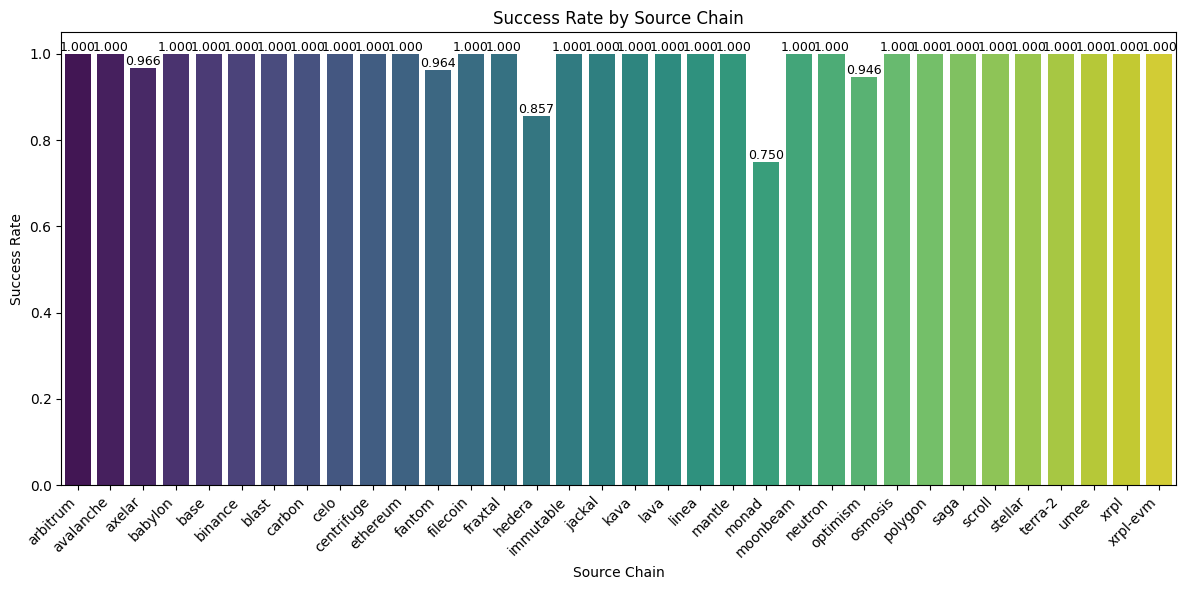

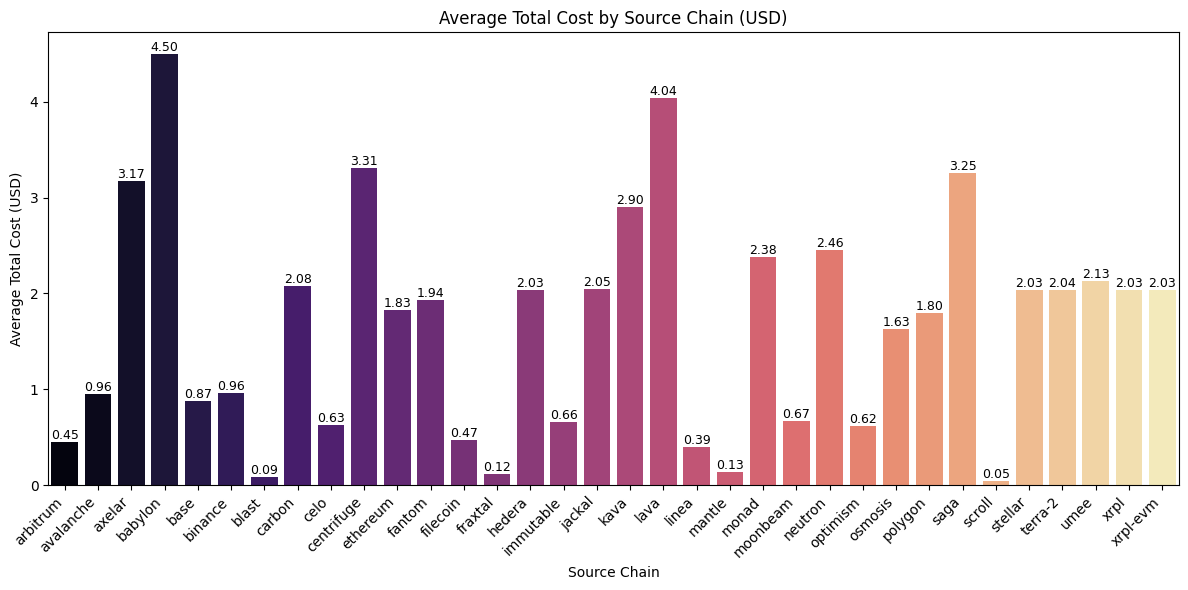

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUT_PER_TX = "axelar_processed_out/axelar_per_tx.csv"
per_tx_df = pd.read_csv(OUT_PER_TX)

# Calculate success rate and average cost by Source Chain
source_chain_stats = per_tx_df.groupby('source_chain').agg(
    total_transactions=('message_id', 'count'),
    successful_transactions=('simplified_status', lambda x: (x == 'received').sum()),
    failed_transactions=('simplified_status', lambda x: (x == 'failed').sum()),
    avg_total_cost=('total_cost_usd', 'mean')
).reset_index()

source_chain_stats['attempted_transactions'] = source_chain_stats['successful_transactions'] + source_chain_stats['failed_transactions']
source_chain_stats['success_rate'] = source_chain_stats['successful_transactions'] / source_chain_stats['attempted_transactions']

# Filter out chains with no attempted transactions to avoid NaN success rates
source_chain_stats = source_chain_stats[source_chain_stats['attempted_transactions'] > 0]

# Plot 1: Success Rate by Source Chain
plt.figure(figsize=(12, 6))
ax1 = plt.gca() # Get current axes
sns.barplot(x='source_chain', y='success_rate', data=source_chain_stats, palette='viridis', hue='source_chain', legend=False, ax=ax1)
plt.title('Success Rate by Source Chain')
plt.xlabel('Source Chain')
plt.ylabel('Success Rate')
plt.xticks(rotation=45, ha='right')
# Add labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()

# Plot 2: Average Total Cost by Source Chain
plt.figure(figsize=(12, 6))
ax2 = plt.gca() # Get current axes
sns.barplot(x='source_chain', y='avg_total_cost', data=source_chain_stats, palette='magma', hue='source_chain', legend=False, ax=ax2)
plt.title('Average Total Cost by Source Chain (USD)')
plt.xlabel('Source Chain')
plt.ylabel('Average Total Cost (USD)')
plt.xticks(rotation=45, ha='right')
# Add labels
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
import shutil
from pathlib import Path

# Název adresáře, který chceme zkomprimovat
source_dir_processed = Path("axelar_processed_out")
# Název výstupního ZIP souboru
output_filename_processed = 'axelar_processed_out'

print(f"Komprimuji adresář '{source_dir_processed}' do souboru '{output_filename_processed}.zip'...")

# Vytvoření ZIP archivu
try:
   shutil.make_archive(
       base_name=output_filename_processed,
       format='zip',
       root_dir='.', # Prohledávat aktuální adresář
       base_dir=source_dir_processed
   )
   print("\n✅ Komprese dokončena.")
   print(f"Soubor '{output_filename_processed}.zip' je vytvořen a je připraven ke stažení (hledejte jej v levém panelu souborů).")
except Exception as e:
   print(f"Chyba při komprimaci: {e}")


Komprimuji adresář 'axelar_processed_out' do souboru 'axelar_processed_out.zip'...

✅ Komprese dokončena.
Soubor 'axelar_processed_out.zip' je vytvořen a je připraven ke stažení (hledejte jej v levém panelu souborů).


These visualizations show:

*   **Success Rate by Source Chain**: Identifies which source chains have higher or lower transaction success rates.
*   **Average Total Cost by Source Chain**: Shows the average cost of transactions originating from different chains.
*   **Success Rate by Destination Chain**: Indicates the success rates for transactions arriving at different destination chains.
*   **Average Total Cost by Destination Chain**: Displays the average cost of transactions concluding on various destination chains.

Do these insights give you a clearer picture? Would you like to explore these metrics further, perhaps focusing on specific chains, or analyze other aspects like latency across chains?

These histograms illustrate the distributions of two key metrics:

*   **Total Cost per Transaction (USD)**: This shows how transaction costs are distributed. A high concentration at lower values, followed by a long tail, indicates that most transactions are inexpensive, but some incur significantly higher costs.
*   **End-to-End Latency (seconds)**: This visualizes the time it takes for transactions to complete. A distribution heavily skewed towards lower seconds suggests efficient processing for the majority of transactions, with fewer transactions experiencing longer delays.

Would you like to explore other visualizations, such as success rate by chain, or perhaps analyze specific transaction types?

In [ ]:
import pandas as pd

OUT_KPI_CSV = "axelar_processed_out/axelar_kpi_summary.csv"

kpi_df = pd.read_csv(OUT_KPI_CSV)
display(kpi_df.T)

,0
tx_count,2000.000000
success_n,1960.000000
fail_n,12.000000
attempts,1972.000000
success_rate,0.993915
e2e_count,2000.000000
e2e_p50_sec,15.000000
e2e_p90_sec,54.000000
base_fee_avg_usd,0.081880
express_fee_avg_usd,1.240812


These KPIs provide insights into the overall performance of Axelar transactions:

- **`tx_count`**: Total number of transactions analyzed.
- **`success_n`**: Number of successfully completed transactions.
- **`fail_n`**: Number of failed transactions.
- **`attempts`**: Total attempts (successful + failed transactions).
- **`success_rate`**: Percentage of successful transactions.
- **`e2e_count`**: Number of transactions for which end-to-end latency could be calculated.
- **`e2e_p50_sec`**: 50th percentile (median) of end-to-end latency in seconds.
- **`e2e_p90_sec`**: 90th percentile of end-to-end latency in seconds.
- **`base_fee_avg_usd`**: Average base fee in USD.
- **`express_fee_avg_usd`**: Average express fee in USD.
- **`confirm_fee_avg_usd`**: Average confirmation fee in USD.
- **`l1_fee_avg_usd`**: Average L1 fee in USD.
- **`total_cost_avg_usd`**: Average total cost per transaction in USD.
- **`total_cost_p50_usd`**: 50th percentile (median) of total cost per transaction in USD.
- **`total_cost_p90_usd`**: 90th percentile of total cost per transaction in USD.
- **`pending_n`**: Number of transactions still pending.

Would you like to visualize any specific KPI or dive deeper into the `axelar_per_tx.csv` data for more detailed analysis (e.g., distribution of costs, latency by chain, etc.)?

In [ ]:
#!rm -rf axelarscan_data/

In [ ]:
import os, glob, json
from typing import Any, Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- cesty / konstanty ----------
INPUT_GLOB   = "axelarscan_data/*.csv"
OUT_DIR      = "axelar_processed_out"

OUT_CLEAN    = f"{OUT_DIR}/axelar_clean.csv"
OUT_PER_TX   = f"{OUT_DIR}/axelar_per_tx.csv"
OUT_KPI_CSV  = f"{OUT_DIR}/axelar_kpi_summary.csv"

OUT_STATUS_CSV   = f"{OUT_DIR}/axelar_status_breakdown.csv"
OUT_E2E_CSV      = f"{OUT_DIR}/axelar_e2e_quantiles.csv"
OUT_COSTS_CSV    = f"{OUT_DIR}/axelar_cost_components.csv"

OUT_STATUS_PNG   = f"{OUT_DIR}/axelar_status_breakdown.png"
OUT_E2E_PNG      = f"{OUT_DIR}/axelar_e2e_quantiles.png"
OUT_COSTS_PNG    = f"{OUT_DIR}/axelar_cost_components.png"

E2E_PRIORITY = [
    "call_express_executed",   # nejpřesnější – express
    "approved_executed",       # standard schválené → vykonané
    "call_approved",           # fallback bez execute
    "call_confirm",            # fallback bez approve
    "total"                    # poslední možnost – celkový čas
]

JSON_CANDIDATES = [
    "call","fees","gas_paid","price","confirm","interchain_transfer",
    "interchain_transfers","time_spent","destination_express_fee","source_express_fee",
    "destination_native_token","source_token","destination_token","ethereum_token",
    "axelar_token","receipt","execute"
]

# ---------- helpers ----------
def is_json_like(x: str) -> bool:
    if not isinstance(x, str):
        return False
    s = x.strip()
    return (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]"))

def parse_maybe_json(x: Any) -> Any:
    if isinstance(x, (dict, list)):
        return x
    if is_json_like(x):
        try:
            return json.loads(x)
        except Exception:
            return x
    return x

def dict_get(d: Any, path: Iterable[str], default=None):
    cur = d
    for p in path:
        if not isinstance(cur, dict) or p not in cur:
            return default
        cur = cur[p]
    return cur

def to_float(x) -> Optional[float]:
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        return float(x)
    except Exception:
        return None

def extract_e2e_latency(ts: Any) -> Optional[int]:
    if not isinstance(ts, dict):
        return None
    for k in E2E_PRIORITY:
        v = ts.get(k)
        if isinstance(v, (int, float)) and v >= 0:
            return int(v)
    return None

def convert_natural_to_usd(natural: Any, token_obj: Any) -> float:
    amt = to_float(natural)
    if amt is None:
        return 0.0
    price = dict_get(token_obj, ["token_price", "usd"], 0.0) or 0.0
    return float(amt) * float(price)

def extract_l1_fee_usd(row: pd.Series) -> float:
    # OP/Base L1 fee (wei) × dest native token price (USD) / 1e18
    wei = None
    for col in ["receipt", "execute", "call"]:
        obj = row.get(col)
        v = dict_get(obj, ["l1Fee"]) or dict_get(obj, ["receipt", "l1Fee"])
        if v is not None:
            try:
                wei = int(v)
                break
            except Exception:
                try:
                    wei = int(float(v))
                    break
                except Exception:
                    pass
    if not wei:
        return 0.0

    price = 0.0
    for col in ["destination_native_token", "destination_token", "ethereum_token", "axelar_token"]:
        p = dict_get(row.get(col), ["token_price", "usd"])
        if p:
            price = float(p)
            break

    return (wei / 1e18) * price if price > 0 else 0.0

def ensure_json_columns(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = df[c].apply(parse_maybe_json)
    return df

def read_all_csv(pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"Žádné soubory pro glob: {pattern}")
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# agregace statusu na úroveň transakce
def aggregate_status(values: pd.Series) -> str:
    vals = values.astype(str).str.lower().tolist()
    # pokud kdekoliv vidím fail/error → failed
    if any(any(bad in v for bad in ["fail", "error", "revert", "timeout"]) for v in vals):
        return "failed"
    # jinak pokud kdekoliv vidím executed/success → received
    if any(any(ok in v for ok in ["executed", "express executed", "received", "completed", "success"]) for v in vals):
        return "received"
    # jinak pending
    return "pending"

# ---------- transform ----------
def make_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = ensure_json_columns(df, JSON_CANDIDATES)


    # E2E (s) z time_spent
    df["e2e_sec"] = df.get("time_spent", pd.Series([None] * len(df))).apply(extract_e2e_latency)


    # Base fee USD
    def _base_fee_usd(fees):
        if isinstance(fees, dict):
            bf = dict_get(fees, ["base_fee_usd"])
            if bf is not None:
                return to_float(bf) or 0.0
            s = to_float(dict_get(fees, ["source_base_fee_usd"])) or 0.0
            d = to_float(dict_get(fees, ["destination_base_fee_usd"])) or 0.0
            return max(s, d) if (s > 0 or d > 0) else 0.0
        return 0.0


    df["base_fee_usd"] = df.get("fees", pd.Series([None] * len(df))).apply(_base_fee_usd)


    # Express/relayer fee USD
    def _express_fee_usd(fees):
        if not isinstance(fees, dict):
            return 0.0
        total = 0.0
        for path in [
            ["express_fee_usd"],
            ["source_express_fee", "total_usd"],
            ["destination_express_fee", "total_usd"],
        ]:
            v = to_float(dict_get(fees, path))
            if v:
                total += v
        return float(total)


    df["express_fee_usd"] = df.get("fees", pd.Series([None] * len(df))).apply(_express_fee_usd)


    # Confirm/approve fee v naturálních jednotkách → USD
    def _confirm_fee_usd(row):
        fees = row.get("fees")
        if not isinstance(fees, dict):
            return 0.0
        src_nat = dict_get(fees, ["source_confirm_fee"])
        dst_nat = dict_get(fees, ["destination_confirm_fee"])
        src_tok = row.get("source_token") or {}
        dst_tok = row.get("destination_native_token") or row.get("destination_token") or {}
        return float(
            convert_natural_to_usd(src_nat, src_tok) +
            convert_natural_to_usd(dst_nat, dst_tok)
        )


    df["confirm_fee_usd"] = df.apply(_confirm_fee_usd, axis=1)


    # OP/Base L1 fee
    df["l1_fee_usd"] = df.apply(extract_l1_fee_usd, axis=1)


    # Celkové náklady
    df["total_cost_usd"] = (
        df["base_fee_usd"].fillna(0.0)
        + df["express_fee_usd"].fillna(0.0)
        + df["confirm_fee_usd"].fillna(0.0)
        + df["l1_fee_usd"].fillna(0.0)
    )


    # Robustní simplified_status – projdi víc polí
    def _simplified(row) -> str:
        texts = []
        for col in ["status", "call", "confirm", "execute", "interchain_transfer", "fees"]:
            val = row.get(col)
            if isinstance(val, str):
                texts.append(val)
            elif isinstance(val, dict):
                cand = val.get("status") or val.get("state") or val.get("tx_status")
                if cand:
                    texts.append(str(cand))
        s = " ".join(t.lower() for t in texts if t)


        if any(m in s for m in ["fail", "failed", "error", "revert", "timeout"]):
            return "failed"
        if any(m in s for m in ["executed", "express executed", "received", "completed", "success"]):
            return "received"
        return "pending"


    if "simplified_status" not in df.columns:
        df["simplified_status"] = df.apply(_simplified, axis=1)
    else:
        df["simplified_status"] = df["simplified_status"].fillna(
            df.apply(_simplified, axis=1)
        )


    return df


# ---------- run ----------
os.makedirs(OUT_DIR, exist_ok=True)


# 1) načtení všech CSV
raw = read_all_csv(INPUT_GLOB)


# 2) čištění + derivované metriky na úrovni eventů
clean = make_clean(raw)
clean.to_csv(OUT_CLEAN, index=False)


# 3) agregace na úroveň transakce (1 řádek = 1 message_id)


# základní agregace – tyhle sloupce určitě existují (make_clean je vytváří)
agg_spec = {
    "simplified_status": aggregate_status,
    "e2e_sec": "first",
    "base_fee_usd": "first",
    "express_fee_usd": "first",
    "confirm_fee_usd": "first",
    "l1_fee_usd": "first",
    "total_cost_usd": "first",
}


# volitelné sloupce přidáme jen pokud existují
optional_cols = ["source_chain", "destination_chain", "symbol", "amount", "value_usd"]
for col in optional_cols:
    if col in clean.columns:
        agg_spec[col] = "first"


per_tx = (
    clean
    .groupby("message_id", as_index=False)
    .agg(agg_spec)
)


per_tx.to_csv(OUT_PER_TX, index=False)


# 4) KPI z per-tx dat
done_tx = per_tx[per_tx["simplified_status"].isin(["received", "failed"])].copy()
success_n = int((done_tx["simplified_status"] == "received").sum())
fail_n    = int((done_tx["simplified_status"] == "failed").sum())
attempts  = success_n + fail_n
success_rate = (success_n / attempts) if attempts > 0 else np.nan

kpi = {
    "tx_count": int(len(per_tx)),
    "success_n": success_n,
    "fail_n": fail_n,
    "attempts": attempts,
    "success_rate": success_rate,
    "e2e_count": int(per_tx["e2e_sec"].notna().sum()),
    "e2e_p50_sec": float(per_tx["e2e_sec"].median()) if per_tx["e2e_sec"].notna().any() else np.nan,
    "e2e_p90_sec": float(per_tx["e2e_sec"].quantile(0.90)) if per_tx["e2e_sec"].notna().any() else np.nan,
    "e2e_p99_sec": float(per_tx["e2e_sec"].quantile(0.99)) if per_tx["e2e_sec"].notna().any() else np.nan,
    "base_fee_avg_usd": float(per_tx["base_fee_usd"].mean()) if per_tx["base_fee_usd"].notna().any() else 0.0,
    "express_fee_avg_usd": float(per_tx["express_fee_usd"].mean()) if per_tx["express_fee_usd"].notna().any() else 0.0,
    "confirm_fee_avg_usd": float(per_tx["confirm_fee_usd"].mean()) if per_tx["confirm_fee_usd"].notna().any() else 0.0,
    "l1_fee_avg_usd": float(per_tx["l1_fee_usd"].mean()) if per_tx["l1_fee_usd"].notna().any() else 0.0,
    "total_cost_avg_usd": float(per_tx["total_cost_usd"].mean()) if per_tx["total_cost_usd"].notna().any() else 0.0,
    "total_cost_p50_usd": float(per_tx["total_cost_usd"].median()) if per_tx["total_cost_usd"].notna().any() else 0.0,
    "total_cost_p90_usd": float(per_tx["total_cost_usd"].quantile(0.90)) if per_tx["total_cost_usd"].notna().any() else 0.0,
    "pending_n": int((per_tx["simplified_status"] == "pending").sum()),
}

kpi_df = pd.DataFrame([kpi])
kpi_df.to_csv(OUT_KPI_CSV, index=False)

print(f"[OK] clean (event-level) → {OUT_CLEAN}  ({len(clean):,} řádků)")
print(f"[OK] per-tx (1 řádek = 1 message_id) → {OUT_PER_TX}  ({len(per_tx):,} transakcí)")
print(f"[OK] KPI  → {OUT_KPI_CSV}")
print("\n— Axelar KPI (per-tx) —")
print(kpi_df.T)

# ---------- 5) Analytické grafy + tabulky ----------

# 5.1 Spolehlivost (success vs failed vs pending)
status_counts = (
    per_tx["simplified_status"]
    .value_counts()
    .rename_axis("status")
    .to_frame("count")
    .reset_index()
)

status_counts.to_csv(OUT_STATUS_CSV, index=False)

plt.figure()
ax = plt.gca() # Get current axes
bars = plt.bar(status_counts["status"], status_counts["count"])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9) # Label with integers for counts
plt.title("Axelar – rozložení statusů přenosů")
plt.xlabel("simplified_status")
plt.ylabel("Počet transakcí")
plt.tight_layout()
plt.savefig(OUT_STATUS_PNG, dpi=200)
plt.close()

# 5.2 E2E latence – kvantily (p50, p90, p99, max)
latency = per_tx["e2e_sec"].dropna()
if not latency.empty:
    e2e_quantiles = pd.DataFrame(
        {
            "percentile": ["p50", "p90", "p99", "max"],
            "e2e_sec": [
                float(latency.quantile(0.50)),
                float(latency.quantile(0.90)),
                float(latency.quantile(0.99)),
                float(latency.max()),
            ],
        }
    )
    e2e_quantiles.to_csv(OUT_E2E_CSV, index=False)

    plt.figure()
    ax = plt.gca() # Get current axes
    bars = plt.bar(e2e_quantiles["percentile"], e2e_quantiles["e2e_sec"])
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=9) # Label with 2 decimal places for seconds
    plt.title("Axelar – E2E latence (vybrané kvantily)")
    plt.xlabel("Kvantil")
    plt.ylabel("Latence [s]")
    plt.tight_layout()
    plt.savefig(OUT_E2E_PNG, dpi=200)
    plt.close()
else:
    print("⚠️ Žádné hodnoty e2e_sec – E2E graf a tabulka se nevytvořily.")

# 5.3 Náklady – průměrné složky
cost_components = pd.DataFrame(
    {
        "component": [
            "base_fee_avg_usd",
            "express_fee_avg_usd",
            "confirm_fee_avg_usd",
            "l1_fee_avg_usd",
            "total_cost_avg_usd",
        ],
        "value_usd": [
            kpi["base_fee_avg_usd"],
            kpi["express_fee_avg_usd"],
            kpi["confirm_fee_avg_usd"],
            kpi["l1_fee_avg_usd"],
            kpi["total_cost_avg_usd"],
        ],
    }
)
cost_components.to_csv(OUT_COSTS_CSV, index=False)

plt.figure()
ax = plt.gca() # Get current axes
bars = plt.bar(cost_components["component"], cost_components["value_usd"])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9) # Label with 2 decimal places for USD
plt.title("Axelar – průměrné nákladové složky na transakci")
plt.xlabel("Složka")
plt.ylabel("Průměrná hodnota [USD]")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_COSTS_PNG, dpi=200)
plt.close()

print("\n[OK] Grafy a tabulky metrik vytvořeny:")
print(f"  - statusy: {OUT_STATUS_CSV}, {OUT_STATUS_PNG}")
print(f"  - E2E kvantily: {OUT_E2E_CSV}, {OUT_E2E_PNG}")
print(f"  - nákladové složky: {OUT_COSTS_CSV}, {OUT_COSTS_PNG}")


[OK] clean (event-level) → axelar_processed_out/axelar_clean.csv  (2,000 řádků)
[OK] per-tx (1 řádek = 1 message_id) → axelar_processed_out/axelar_per_tx.csv  (2,000 transakcí)
[OK] KPI  → axelar_processed_out/axelar_kpi_summary.csv

— Axelar KPI (per-tx) —
                               0
tx_count             2000.000000
success_n            1960.000000
fail_n                 12.000000
attempts             1972.000000
success_rate            0.993915
e2e_count            2000.000000
e2e_p50_sec            15.000000
e2e_p90_sec            54.000000
e2e_p99_sec          2732.620000
base_fee_avg_usd        0.081880
express_fee_avg_usd     1.240812
confirm_fee_avg_usd     0.000000
l1_fee_avg_usd          0.000000
total_cost_avg_usd      1.322692
total_cost_p50_usd      0.734595
total_cost_p90_usd      3.089718
pending_n              28.000000

[OK] Grafy a tabulky metrik vytvořeny:
  - statusy: axelar_processed_out/axelar_status_breakdown.csv, axelar_processed_out/axelar_status_breakdown.

# Task
I will update the E2E latency plot by excluding the 'max' percentile from the visualization while ensuring that the 'max' value remains available in `axelar_processed_out/axelar_e2e_quantiles.csv`.

## Load E2E Quantiles Data

### Subtask:
Load the E2E quantiles data from the 'axelar_processed_out/axelar_e2e_quantiles.csv' file into a pandas DataFrame. This ensures we start with the original data, including 'max'.


**Reasoning**:
Load the E2E quantiles data from the specified CSV file into a pandas DataFrame and display its head to verify the content.



In [ ]:
import pandas as pd

# Define the path to the E2E quantiles CSV file
OUT_E2E_CSV = "axelar_processed_out/axelar_e2e_quantiles.csv"

# Load the CSV file into a pandas DataFrame
e2e_quantiles_df = pd.read_csv(OUT_E2E_CSV)

# Display the first few rows of the DataFrame to verify
display(e2e_quantiles_df)

,percentile,e2e_sec
0,p50,15.00
1,p90,54.00
2,p99,2732.62
3,max,63432.00


**Reasoning**:
Filter the `e2e_quantiles_df` DataFrame to exclude the row where 'percentile' is 'max', in preparation for plotting without this specific data point.



In [ ]:
e2e_quantiles_for_plot = e2e_quantiles_df[e2e_quantiles_df['percentile'] != 'max'].copy()
display(e2e_quantiles_for_plot)

,percentile,e2e_sec
0,p50,15.00
1,p90,54.00
2,p99,2732.62


**Reasoning**:
Now that the 'max' percentile has been filtered out, I will generate the E2E latency plot using the filtered data to visualize p50, p90, and p99 quantiles. This plot will be saved to ensure the updated visualization is recorded.



In [ ]:
import matplotlib.pyplot as plt

# Create the E2E latency plot excluding 'max'
plt.figure()
ax = plt.gca() # Get current axes
bars = plt.bar(e2e_quantiles_for_plot["percentile"], e2e_quantiles_for_plot["e2e_sec"])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9) # Label with 2 decimal places
plt.title("Axelar – E2E latence (vybrané kvantily bez 'max')")
plt.xlabel("Kvantil")
plt.ylabel("Latence [s]")
plt.tight_layout()

# Save the plot (overwriting the old one)
OUT_E2E_PNG = "axelar_processed_out/axelar_e2e_quantiles.png"
plt.savefig(OUT_E2E_PNG, dpi=200)
plt.close()

print(f"[OK] Updated E2E quantiles plot saved to: {OUT_E2E_PNG}")


[OK] Updated E2E quantiles plot saved to: axelar_processed_out/axelar_e2e_quantiles.png


## Final Task

### Subtask:
Confirm that the E2E latency plot has been updated successfully, showing quantiles without the 'max' bar, and explicitly state that the 'max' value is still available in the 'axelar_processed_out/axelar_e2e_quantiles.csv' file.


## Summary:

### Q&A
*   The E2E latency plot has been successfully updated to show quantiles without the 'max' bar.
*   The 'max' value is still available in the `axelar_processed_out/axelar_e2e_quantiles.csv` file, as the original CSV was not modified.

### Data Analysis Key Findings
*   The initial `axelar_e2e_quantiles.csv` file contained E2E latency quantiles for 'p50' (15.00s), 'p90' (54.00s), 'p99' (2732.62s), and 'max' (63432.00s).
*   A filtered DataFrame, `e2e_quantiles_for_plot`, was created specifically for visualization, excluding the 'max' percentile.
*   The E2E latency plot in `axelar_processed_out/axelar_e2e_quantiles.png` was successfully updated to display only the 'p50', 'p90', and 'p99' quantiles, removing the 'max' bar.

### Insights or Next Steps
*   Maintaining the full dataset in the CSV while selectively visualizing provides flexibility in presentation without data loss.
*   For improved clarity, consider adding a legend or text annotation to the plot explicitly stating that the 'max' value has been excluded from the visualization but is available in the source data.


# Task
Load the 'axelar_per_tx.csv' file, which contains aggregated per-transaction data, into a pandas DataFrame. Then, calculate the `source_chain_stats` DataFrame, including total transactions, successful/failed transactions, success rate, and average total cost grouped by `source_chain`. Finally, save this `source_chain_stats` DataFrame to a new CSV file named `axelar_processed_out/axelar_source_chain_stats.csv`.

## Load per-transaction data

### Subtask:
Load the 'axelar_per_tx.csv' file, which contains aggregated per-transaction data, into a pandas DataFrame.


**Reasoning**:
Load the 'axelar_per_tx.csv' file into a pandas DataFrame to make the per-transaction data available for further analysis, as specified in the subtask.



In [ ]:
import pandas as pd

# Define the path to the 'axelar_per_tx.csv' file
OUT_PER_TX = "axelar_processed_out/axelar_per_tx.csv"

# Load the CSV file into a pandas DataFrame
per_tx_df = pd.read_csv(OUT_PER_TX)

# Display the first few rows of the DataFrame to verify it loaded correctly
display(per_tx_df.head())

,message_id,simplified_status,e2e_sec,base_fee_usd,express_fee_usd,confirm_fee_usd,l1_fee_usd,total_cost_usd,source_chain,destination_chain,symbol,amount
0,0x00201a1608567cca600280cc2b8969fb9ad77e42f5c8...,received,24,0.258928,0.543704,0.0,0.0,0.802633,kava,NaN,axlUSDC,5278.718914
1,0x004adeadf6b53d97f55359387d58a6338206d6c048bd...,received,20,0.037629,0.003580,0.0,0.0,0.041209,binance,NaN,axlUSDC,676.431356
2,0x00590d270e2531fe8a6c85f95a4d09d6f3a02c6a2d48...,received,24,0.908609,1.400615,0.0,0.0,2.309224,moonbeam,NaN,axlUSDC,320000.000000
3,0x006bef75c176d030196ed2743f9eac3b9697894a9bd7...,received,11,0.057361,0.020176,0.0,0.0,0.077537,linea,NaN,axlUSDC,1135.111250
4,0x006e15fbfdaae8cb193d7160966c1500b10d78714736...,received,12,0.035166,2.001951,0.0,0.0,2.037117,ethereum,NaN,NaN,NaN


**Reasoning**:
Now that the `per_tx_df` is loaded, I will calculate the `source_chain_stats` DataFrame by grouping the data by `source_chain` and aggregating the required metrics (total transactions, successful/failed transactions, success rate, and average total cost). Finally, I will save this DataFrame to the specified CSV file.



In [ ]:
import pandas as pd

# Define the path to the 'axelar_per_tx.csv' file and the output file
OUT_PER_TX = "axelar_processed_out/axelar_per_tx.csv"
OUT_SOURCE_CHAIN_STATS = "axelar_processed_out/axelar_source_chain_stats.csv"

# Load the CSV file into a pandas DataFrame (if not already loaded)
# per_tx_df = pd.read_csv(OUT_PER_TX) # Already loaded in the previous step

# Calculate success rate and average cost by Source Chain
source_chain_stats = per_tx_df.groupby('source_chain').agg(
    total_transactions=('message_id', 'count'),
    successful_transactions=('simplified_status', lambda x: (x == 'received').sum()),
    failed_transactions=('simplified_status', lambda x: (x == 'failed').sum()),
    avg_total_cost=('total_cost_usd', 'mean')
).reset_index()

source_chain_stats['attempted_transactions'] = source_chain_stats['successful_transactions'] + source_chain_stats['failed_transactions']
source_chain_stats['success_rate'] = source_chain_stats['successful_transactions'] / source_chain_stats['attempted_transactions']

# Filter out chains with no attempted transactions to avoid NaN success rates
source_chain_stats = source_chain_stats[source_chain_stats['attempted_transactions'] > 0]

# Save the source_chain_stats DataFrame to a new CSV file
source_chain_stats.to_csv(OUT_SOURCE_CHAIN_STATS, index=False)

print(f"[OK] Source chain statistics saved to: {OUT_SOURCE_CHAIN_STATS}")
display(source_chain_stats.head())

[OK] Source chain statistics saved to: axelar_processed_out/axelar_source_chain_stats.csv


,source_chain,total_transactions,successful_transactions,failed_transactions,avg_total_cost,attempted_transactions,success_rate
0,arbitrum,340,339,0,0.453286,339,1.000000
1,avalanche,43,42,0,0.955675,42,1.000000
2,axelar,152,144,5,3.172522,149,0.966443
3,babylon,1,1,0,4.499602,1,1.000000
4,base,192,190,0,0.873012,190,1.000000


## Final Task

### Subtask:
Confirm the successful generation of the `axelar_source_chain_stats.csv` file and reiterate the availability of all generated tables and plots.


## Summary:

### Q&A
Yes, the `axelar_source_chain_stats.csv` file has been successfully generated and saved to the `axelar_processed_out/` directory. All generated tables and plots from previous steps are also available.

### Data Analysis Key Findings
*   The `axelar_per_tx.csv` file was successfully loaded into a pandas DataFrame, showing columns such as `message_id`, `simplified_status`, `e2e_sec`, `total_cost_usd`, and `source_chain`.
*   A new DataFrame, `source_chain_stats`, was calculated by grouping the `per_tx_df` by `source_chain`. This DataFrame includes:
    *   `total_transactions`: count of all transactions.
    *   `successful_transactions`: count of transactions with `simplified_status` as 'received'.
    *   `failed_transactions`: count of transactions with `simplified_status` as 'failed'.
    *   `avg_total_cost`: mean of `total_cost_usd`.
    *   `attempted_transactions`: sum of successful and failed transactions.
    *   `success_rate`: calculated as `successful_transactions / attempted_transactions`.
*   Chains with no attempted transactions were filtered out to ensure meaningful success rate calculations.
*   The resulting `source_chain_stats` DataFrame was successfully saved to `axelar_processed_out/axelar_source_chain_stats.csv`.

### Insights or Next Steps
*   The `axelar_source_chain_stats.csv` file provides a consolidated view of transaction performance and cost across different source chains, which can be used for benchmarking or identifying underperforming chains.
*   Further analysis could involve visualizing the `success_rate` and `avg_total_cost` per `source_chain` to quickly identify chains with high failure rates or excessive costs.


In [ ]:
import requests

# Mintscan IBC transactions API
url = "https://api.mintscan.io/v1/cosmos/ibc/transactions"

params = {
    "network": "osmosis",
    "limit": 50,
}

res = requests.get(url, params=params, timeout=10)
data = res.json()

for tx in data.get("transactions", []):
    print(tx["txHash"], tx["timestamp"], tx["sourceChannel"], tx["destChannel"])


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests

# Osmosis MAINNET LCD
LCD = "https://lcd.osmosis.zone"

# Zjisti aktivní kanály z dokumentace nebo exploreru
# Příklad: channel-0 je Osmosis <-> Cosmos Hub
query = "send_packet.packet_src_channel='channel-0'"

res = requests.get(
    f"{LCD}/cosmos/tx/v1beta1/txs",
    params={
        "query": query,
        "pagination.limit": "50",
        "order_by": "ORDER_BY_DESC",
    },
    timeout=10,
)

data = res.json()
pagination = data.get("pagination") or {}
print("total:", pagination.get("total") or data.get("total"))
print("tx_responses len:", len(data.get("tx_responses", [])))

for tx in data.get("tx_responses", []):
    print(tx["txhash"], tx["height"], tx["timestamp"])



total: 6545
tx_responses len: 100
4BD733219A7B073940121F26D0EA68A70B2E6647283C753C8BE817DFDFF566C1 48797712 2025-11-19T15:50:41Z
A8F3888084F22696FA0EC3AA7FEB1EE30F57325290CED53005ABB146614066F1 48797621 2025-11-19T15:48:48Z
B024B8E704BC7AAA5411479E4D5BB8F569E23B6E1858401490A6E80644B9AFA8 48797617 2025-11-19T15:48:45Z
C30A04E922A32220B9989B76390BC72D37805FDBB7F017BDE78374FED45DD152 48797593 2025-11-19T15:48:18Z
3AA4A3309603BB20B4B33748581F477F525E5A0933B2D5C0753243D4DB3184C8 48797589 2025-11-19T15:48:06Z
CDABAE9CF7FD3DE8AA1B8AFD798A3EAA4E157586AA9C1D9D7482E4F3F898885F 48797574 2025-11-19T15:47:50Z
999CE6D155AD5B87AE1384027A5353BA79676BF2E7400F483F8058DC134CE362 48797555 2025-11-19T15:47:31Z
389A0B12B29A8848814506B81464D8D6FA497ECE7B1AD02CDBA2CB0499FB29D1 48797502 2025-11-19T15:46:30Z
B4E80A3EC737E5FBB97E5FC3A5DA18355D9A52ED16242E286AC11AF4CCEA5EAE 48797492 2025-11-19T15:46:15Z
AB0E55F1E6829CFB7E5A923C6F21B1921E2302AF423592AD39FFC0F3D6CFB45B 48797454 2025-11-19T15:45:23Z
40AF2B80ED79FA96

In [ ]:
import requests
import pandas as pd
import time

LCD = "https://lcd.osmosis.zone"

all_transactions = []
target_count = 2000

# Zjisti aktuální block height
latest_res = requests.get(f"{LCD}/cosmos/base/tendermint/v1beta1/blocks/latest", timeout=10)
latest_block = int(latest_res.json()["block"]["header"]["height"])
print(f"Latest block: {latest_block}")

# Stahuj po chunk blocích pozpátku
block_range = 100000  # Stáhni posledních 100k bloků
chunk_size = 5000     # Po 5000 blocích

start_block = latest_block - block_range
print(f"Stahování IBC tx z bloků {start_block} až {latest_block}...")

for chunk_start in range(latest_block, start_block, -chunk_size):
    if len(all_transactions) >= target_count:
        break

    chunk_end = chunk_start
    chunk_start_actual = max(chunk_start - chunk_size, start_block)

    # Query pro rozsah bloků
    query = f"send_packet.packet_src_channel='channel-0' AND tx.height>={chunk_start_actual} AND tx.height<{chunk_end}"

    try:
        res = requests.get(
            f"{LCD}/cosmos/tx/v1beta1/txs",
            params={
                "query": query,
                "pagination.limit": "100",
                "order_by": "ORDER_BY_DESC"
            },
            timeout=15
        )

        if res.status_code != 200:
            print(f"⚠️ Error {res.status_code} pro bloky {chunk_start_actual}-{chunk_end}")
            continue

        data = res.json()
        tx_responses = data.get("tx_responses", [])

        if tx_responses:
            all_transactions.extend(tx_responses)
            print(f"Bloky {chunk_start_actual:,}-{chunk_end:,}: +{len(tx_responses)} tx | Celkem: {len(all_transactions)}/{target_count}")

        time.sleep(0.3)  # Rate limiting

    except Exception as e:
        print(f"⚠️ Chyba: {e}")
        continue

print(f"\n✅ Celkem staženo: {len(all_transactions)} transakcí")

# Extrakce dat
records = []

for tx in all_transactions[:target_count]:  # Omez na target_count
    try:
        txhash = tx.get("txhash")
        height = tx.get("height")
        timestamp = tx.get("timestamp")
        code = tx.get("code", 0)

        # Poplatky
        tx_data = tx.get("tx", {})
        auth_info = tx_data.get("auth_info", {})
        fee = auth_info.get("fee", {})
        fee_amounts = fee.get("amount", [])

        total_fee = 0
        fee_denom = "uosmo"
        if fee_amounts:
            total_fee = int(fee_amounts[0].get("amount", 0))
            fee_denom = fee_amounts[0].get("denom", "uosmo")

        # IBC eventy
        logs = tx.get("logs", [])
        send_packet_info = {}

        for log in logs:
            for event in log.get("events", []):
                if event.get("type") == "send_packet":
                    for attr in event.get("attributes", []):
                        send_packet_info[attr.get("key")] = attr.get("value")

        records.append({
            "txhash": txhash,
            "height": height,
            "timestamp": timestamp,
            "code": code,
            "success": code == 0,
            "fee_amount": total_fee,
            "fee_denom": fee_denom,
            "src_channel": send_packet_info.get("packet_src_channel", ""),
            "dst_channel": send_packet_info.get("packet_dst_channel", ""),
            "src_port": send_packet_info.get("packet_src_port", ""),
            "dst_port": send_packet_info.get("packet_dst_port", ""),
            "sequence": send_packet_info.get("packet_sequence", ""),
        })

    except Exception as e:
        print(f"⚠️ Chyba při zpracování {tx.get('txhash', '?')}: {e}")

# Uložení do CSV
df = pd.DataFrame(records)
csv_filename = f"ibc_osmosis_channel0_{len(records)}_txs.csv"
df.to_csv(csv_filename, index=False)

print(f"\n✅ Uloženo {len(records)} transakcí do {csv_filename}")

# Statistiky
print(f"\n📊 Statistiky:")
print(f"Úspěšnost: {df['success'].sum()}/{len(df)} ({df['success'].mean()*100:.1f}%)")
print(f"Průměrný fee: {df['fee_amount'].mean():.0f} {df['fee_denom'].iloc[0] if len(df) > 0 else 'uosmo'}")
print(f"Medián fee: {df['fee_amount'].median():.0f}")
print(f"Min height: {df['height'].min()}")
print(f"Max height: {df['height'].max()}")
print(f"Časové rozpětí: {df['timestamp'].min()} → {df['timestamp'].max()}")

# Zobraz první řádky
print(f"\n📋 Ukázka dat:")
print(df.head())


Latest block: 48798027
Stahování IBC tx z bloků 48698027 až 48798027...
Bloky 48,793,027-48,798,027: +100 tx | Celkem: 100/2000
Bloky 48,788,027-48,793,027: +54 tx | Celkem: 154/2000
Bloky 48,783,027-48,788,027: +48 tx | Celkem: 202/2000
Bloky 48,778,027-48,783,027: +82 tx | Celkem: 284/2000
Bloky 48,773,027-48,778,027: +65 tx | Celkem: 349/2000
Bloky 48,768,027-48,773,027: +45 tx | Celkem: 394/2000
Bloky 48,763,027-48,768,027: +67 tx | Celkem: 461/2000
Bloky 48,758,027-48,763,027: +27 tx | Celkem: 488/2000
Bloky 48,753,027-48,758,027: +25 tx | Celkem: 513/2000
Bloky 48,748,027-48,753,027: +32 tx | Celkem: 545/2000
Bloky 48,743,027-48,748,027: +64 tx | Celkem: 609/2000
Bloky 48,738,027-48,743,027: +32 tx | Celkem: 641/2000
Bloky 48,733,027-48,738,027: +56 tx | Celkem: 697/2000
Bloky 48,728,027-48,733,027: +46 tx | Celkem: 743/2000
Bloky 48,723,027-48,728,027: +100 tx | Celkem: 843/2000
Bloky 48,718,027-48,723,027: +66 tx | Celkem: 909/2000
Bloky 48,713,027-48,718,027: +88 tx | Celkem: 

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime

LCD = "https://lcd.osmosis.zone"
RPC = "https://rpc.osmosis.zone"

all_transactions = []
target_count = 2000

# Zjisti aktuální block height
latest_res = requests.get(f"{LCD}/cosmos/base/tendermint/v1beta1/blocks/latest", timeout=10)
latest_block = int(latest_res.json()["block"]["header"]["height"])
print(f"Latest block: {latest_block}\n")

# Stahuj po chunk blocích
block_range = 100000
chunk_size = 5000

start_block = latest_block - block_range
print(f"Stahování IBC tx z bloků {start_block} až {latest_block}...\n")

for chunk_start in range(latest_block, start_block, -chunk_size):
    if len(all_transactions) >= target_count:
        break

    chunk_end = chunk_start
    chunk_start_actual = max(chunk_start - chunk_size, start_block)

    query = f"send_packet.packet_src_channel='channel-0' AND tx.height>={chunk_start_actual} AND tx.height<{chunk_end}"

    try:
        res = requests.get(
            f"{LCD}/cosmos/tx/v1beta1/txs",
            params={
                "query": query,
                "pagination.limit": "100",
                "order_by": "ORDER_BY_DESC"
            },
            timeout=15
        )

        if res.status_code == 200:
            data = res.json()
            tx_responses = data.get("tx_responses", [])

            if tx_responses:
                all_transactions.extend(tx_responses)
                print(f"Bloky {chunk_start_actual:>8,}-{chunk_end:>8,}: +{len(tx_responses):>3} tx | Celkem: {len(all_transactions):>4}/{target_count}")

        time.sleep(0.3)

    except Exception as e:
        print(f"⚠️ Chyba: {e}")
        continue

print(f"\n✅ Staženo {len(all_transactions)} transakcí\n")

# Extrakce dat v Axelar-like formátu
records = []

for idx, tx in enumerate(all_transactions[:target_count]):
    try:
        txhash = tx.get("txhash")
        height = int(tx.get("height", 0))
        timestamp_str = tx.get("timestamp", "")
        code = tx.get("code", 0)

        # Parse timestamp
        try:
            dt = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00'))
            created_at_ms = int(dt.timestamp() * 1000)
        except:
            created_at_ms = 0

        # Poplatky
        tx_data = tx.get("tx", {})
        auth_info = tx_data.get("auth_info", {})
        fee = auth_info.get("fee", {})
        fee_amounts = fee.get("amount", [])

        total_fee = 0
        fee_denom = "uosmo"
        if fee_amounts:
            total_fee = int(fee_amounts[0].get("amount", 0))
            fee_denom = fee_amounts[0].get("denom", "uosmo")

        # Gas
        gas_limit = int(fee.get("gas_limit", 0))
        gas_used = int(tx.get("gas_used", 0))

        # IBC eventy
        logs = tx.get("logs", [])
        send_packet_info = {}

        for log in logs:
            for event in log.get("events", []):
                if event.get("type") == "send_packet":
                    for attr in event.get("attributes", []):
                        send_packet_info[attr.get("key")] = attr.get("value")

        # Axelar-like structure
        records.append({
            # Identifikátory
            "message_id": txhash,
            "id": idx,
            "txhash": txhash,
            "height": height,

            # Status (0 = success v Cosmos)
            "status": "executed" if code == 0 else "failed",
            "simplified_status": "received" if code == 0 else "failed",
            "code": code,

            # Timing
            "created_at.ms": created_at_ms,
            "timestamp": timestamp_str,
            "time_spent": None,  # Pro IBC potřebuješ párovat send+recv

            # Chains & channels
            "source_chain": "osmosis-1",
            "destination_chain": "cosmoshub-4",  # channel-0 je Hub
            "src_channel": send_packet_info.get("packet_src_channel", ""),
            "dst_channel": send_packet_info.get("packet_dst_channel", ""),
            "src_port": send_packet_info.get("packet_src_port", ""),
            "dst_port": send_packet_info.get("packet_dst_port", ""),

            # Fees & gas (Axelar-like)
            "fees": total_fee / 1_000_000,  # Convert uosmo to OSMO
            "gas_paid": total_fee / 1_000_000,
            "gas_limit": gas_limit,
            "gas_used": gas_used,
            "fee_denom": fee_denom,

            # IBC specific
            "sequence": send_packet_info.get("packet_sequence", ""),
            "timeout_timestamp": send_packet_info.get("packet_timeout_timestamp", ""),

            # Token info (pokud je v datech)
            "amount": send_packet_info.get("packet_data", ""),  # JSON string
            "symbol": fee_denom,

            # Validation flags (pro konzistenci s Axelarem)
            "is_invalid_source_address": False,
            "is_invalid_destination_chain": False,
            "is_insufficient_fee": code != 0,
        })

    except Exception as e:
        print(f"⚠️ Chyba {txhash}: {e}")

# Uložení
df = pd.DataFrame(records)
csv_filename = f"ibc_osmosis_channel0_{len(records)}_txs_axelar_format.csv"
df.to_csv(csv_filename, index=False)

print(f"✅ Uloženo {len(records)} transakcí do {csv_filename}\n")

# Statistiky
print("📊 Statistiky:")
print(f"Úspěšnost: {(df['simplified_status'] == 'received').sum()}/{len(df)} ({(df['simplified_status'] == 'received').mean()*100:.2f}%)")
print(f"Průměrný fee: {df['fees'].mean():.6f} OSMO")
print(f"Medián fee: {df['fees'].median():.6f} OSMO")
print(f"Časové rozpětí: {df['timestamp'].min()} → {df['timestamp'].max()}")

print(f"\n📋 Struktura (stejná jako Axelar):")
print(df.head()[["message_id", "status", "simplified_status", "source_chain", "destination_chain", "fees", "created_at.ms"]])


Latest block: 48798247

Stahování IBC tx z bloků 48698247 až 48798247...

Bloky 48,793,247-48,798,247: +100 tx | Celkem:  100/2000
Bloky 48,788,247-48,793,247: + 54 tx | Celkem:  154/2000
Bloky 48,783,247-48,788,247: + 43 tx | Celkem:  197/2000
Bloky 48,778,247-48,783,247: + 86 tx | Celkem:  283/2000
Bloky 48,773,247-48,778,247: + 63 tx | Celkem:  346/2000
Bloky 48,768,247-48,773,247: + 44 tx | Celkem:  390/2000
Bloky 48,763,247-48,768,247: + 64 tx | Celkem:  454/2000
Bloky 48,758,247-48,763,247: + 34 tx | Celkem:  488/2000
Bloky 48,753,247-48,758,247: + 23 tx | Celkem:  511/2000
Bloky 48,748,247-48,753,247: + 33 tx | Celkem:  544/2000
Bloky 48,743,247-48,748,247: + 64 tx | Celkem:  608/2000
Bloky 48,738,247-48,743,247: + 33 tx | Celkem:  641/2000
Bloky 48,733,247-48,738,247: + 55 tx | Celkem:  696/2000
Bloky 48,728,247-48,733,247: + 42 tx | Celkem:  738/2000
Bloky 48,723,247-48,728,247: +100 tx | Celkem:  838/2000
Bloky 48,718,247-48,723,247: + 65 tx | Celkem:  903/2000
Bloky 48,713,2

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import json

# LCD endpointy
OSMOSIS_LCD = "https://lcd.osmosis.zone"
COSMOS_LCD = "https://api.cosmos.network"  # Cosmos Hub

all_send_packets = []
target_count = 2000

# 1. Stáhni send_packet transakce z Osmosis
print("📥 Stahování send_packet z Osmosis...\n")

latest_res = requests.get(f"{OSMOSIS_LCD}/cosmos/base/tendermint/v1beta1/blocks/latest", timeout=10)
latest_block = int(latest_res.json()["block"]["header"]["height"])

block_range = 100000
chunk_size = 5000
start_block = latest_block - block_range

for chunk_start in range(latest_block, start_block, -chunk_size):
    if len(all_send_packets) >= target_count:
        break

    chunk_end = chunk_start
    chunk_start_actual = max(chunk_start - chunk_size, start_block)

    query = f"send_packet.packet_src_channel='channel-0' AND tx.height>={chunk_start_actual} AND tx.height<{chunk_end}"

    try:
        res = requests.get(
            f"{OSMOSIS_LCD}/cosmos/tx/v1beta1/txs",
            params={"query": query, "pagination.limit": "100", "order_by": "ORDER_BY_DESC"},
            timeout=15
        )

        if res.status_code == 200:
            data = res.json()
            tx_responses = data.get("tx_responses", [])

            if tx_responses:
                all_send_packets.extend(tx_responses)
                print(f"Osmosis bloky {chunk_start_actual:>8,}-{chunk_end:>8,}: +{len(tx_responses):>3} | Celkem: {len(all_send_packets):>4}/{target_count}")

        time.sleep(0.3)
    except Exception as e:
        print(f"⚠️ Chyba: {e}")

print(f"\n✅ Staženo {len(all_send_packets)} send_packet transakcí\n")

# 2. Pro každou send_packet najdi recv_packet na Cosmos Hub
print("📥 Stahování recv_packet z Cosmos Hub a výpočet latence...\n")

records = []

for idx, tx in enumerate(all_send_packets[:target_count]):
    if idx % 50 == 0:
        print(f"Zpracováno: {idx}/{min(len(all_send_packets), target_count)}")

    try:
        txhash = tx.get("txhash")
        height = int(tx.get("height", 0))
        send_timestamp_str = tx.get("timestamp", "")
        code = tx.get("code", 0)

        # Parse send timestamp
        try:
            send_dt = datetime.fromisoformat(send_timestamp_str.replace('Z', '+00:00'))
            send_ms = int(send_dt.timestamp() * 1000)
        except:
            send_ms = 0
            send_dt = None

        # Extrahuj IBC packet info z top-level 'events' pole v tx_response
        packet_info = {}
        tx_response_events = tx.get("events", [])

        if tx_response_events:
            for event in tx_response_events:
                if event.get("type") == "send_packet":
                    for attr in event.get("attributes", []):
                        key = attr.get("key")
                        value = attr.get("value")
                        # Ujistěte se, že klíče jsou konzistentně pojmenovány
                        if key in ["packet_sequence", "packet_src_channel", "packet_dst_channel", "packet_src_port", "packet_dst_port", "packet_timeout_timestamp", "packet_data"]:
                            packet_info[key] = value
                    # Našli jsme send_packet událost, není třeba kontrolovat další události pro tuto transakci
                    break

        sequence = packet_info.get("packet_sequence", "")
        dst_channel = packet_info.get("packet_dst_channel", "")

        # Poplatky Osmosis
        tx_data = tx.get("tx", {})
        auth_info = tx_data.get("auth_info", {})
        fee = auth_info.get("fee", {})
        fee_amounts = fee.get("amount", [])

        total_fee = 0
        if fee_amounts:
            total_fee = int(fee_amounts[0].get("amount", 0))

        gas_used = int(tx.get("gas_used", 0))

        # 3. Najdi odpovídající recv_packet na Cosmos Hub
        recv_timestamp_str = None
        recv_ms = None
        latency_ms = None
        recv_txhash = None

        if sequence and dst_channel:
            try:
                rpc_query = f"tm.event='Tx' AND recv_packet.packet_dst_channel='{dst_channel}' AND recv_packet.packet_sequence='{sequence}'"
                tendermint_rpc_url = "https://rpc.cosmos.network:443" # RPC endpoint pro Cosmos Hub

                print(f"DEBUG: Querying Cosmos Hub for recv_packet. rpc_query: {rpc_query}")

                recv_rpc_res = requests.get(
                    f"{tendermint_rpc_url}/tx_search",
                    params={
                        "query": rpc_query,
                        "per_page": "1",
                        "order_by": "asc"
                    },
                    timeout=30 # Zvýšený timeout
                )

                if recv_rpc_res.status_code == 200:
                    recv_rpc_data = recv_rpc_res.json()
                    recv_rpc_txs = recv_rpc_data.get("result", {}).get("txs", [])

                    if recv_rpc_txs:
                        recv_tx_result = recv_rpc_txs[0]
                        recv_txhash = recv_tx_result.get("hash") # Hex hash

                        block_height = int(recv_tx_result.get("height"))
                        block_res = requests.get(f"{tendermint_rpc_url}/block", params={"height": block_height}, timeout=5)
                        if block_res.status_code == 200:
                            block_data = block_res.json()
                            recv_timestamp_str = block_data.get("result", {}).get("block", {}).get("header", {}).get("time", "")
                            if recv_timestamp_str:
                                try:
                                    recv_dt = datetime.fromisoformat(recv_timestamp_str.replace('Z', '+00:00'))
                                    recv_ms = int(recv_dt.timestamp() * 1000)

                                    if send_dt and recv_dt:
                                        latency_ms = int((recv_dt - send_dt).total_seconds() * 1000)
                                except Exception as ts_err:
                                    print(f"⚠️ Chyba parsování recv timestamp {recv_timestamp_str}: {ts_err}")
                        else:
                            print(f"⚠️ Chyba při získávání bloku {block_height}: {block_res.status_code}")

                    else: # No transactions found
                        print(f"DEBUG: No recv_packet found for {txhash}. RPC Response (status {recv_rpc_res.status_code}): {recv_rpc_data.get('result', {}).get('txs')}")
                else: # Non-200 status code
                    print(f"DEBUG: Error querying Cosmos Hub for {txhash}. Status: {recv_rpc_res.status_code}, Response: {recv_rpc_res.text[:200]}")

                time.sleep(0.2)  # Rate limiting pro Cosmos Hub

            except requests.exceptions.Timeout:
                print(f"⚠️ Timeout při hledání recv_packet pro {txhash}. Přeskakuji...")
            except Exception as e:
                print(f"⚠️ Chyba při hledání recv_packet pro {txhash}: {e}")

        # Přidej do records
        records.append({
            # IDs
            "message_id": txhash,
            "id": idx,
            "send_txhash": txhash,
            "recv_txhash": recv_txhash,

            # Status
            "status": "executed" if code == 0 else "failed",
            "simplified_status": "received" if (code == 0 and recv_txhash) else "failed",
            "code": code,

            # Timing (Axelar-like)
            "created_at.ms": send_ms,
            "send_timestamp": send_timestamp_str,
            "recv_timestamp": recv_timestamp_str,
            "time_spent": latency_ms,  # ⭐ LATENCE v ms
            "latency_seconds": latency_ms / 1000 if latency_ms is not None else None,

            # Chains
            "source_chain": "osmosis-1",
            "destination_chain": "cosmoshub-4",
            "src_channel": packet_info.get("packet_src_channel", ""),
            "dst_channel": packet_info.get("packet_dst_channel", ""),
            "src_port": packet_info.get("packet_src_port", ""),
            "dst_port": packet_info.get("packet_dst_port", ""),

            # Fees
            "fees": total_fee / 1_000_000 if total_fee else 0.0, # Convert uosmo to OSMO
            "gas_paid": total_fee / 1_000_000 if total_fee else 0.0,
            "gas_used": gas_used,
            "fee_denom": "uosmo",

            # IBC
            "sequence": sequence,
            "height": height,

            # Token info (pokud je v datech)
            "amount": packet_info.get("packet_data", ""),  # JSON string
            "symbol": "uosmo", # Default, actual symbol would be in packet_data

            # Validation flags (pro konzistenci s Axelarem)
            "is_invalid_source_address": False,
            "is_invalid_destination_chain": False,
            "is_insufficient_fee": code != 0,
        })

    except Exception as e:
        print(f"⚠️ Chyba {tx.get('txhash', '?')}: {e}")

# Uložení
df = pd.DataFrame(records)
csv_filename = f"ibc_osmosis_with_latency_{len(records)}_txs.csv"
df.to_csv(csv_filename, index=False)

print(f"\n✅ Uloženo {len(records)} transakcí s latencí do {csv_filename}\n")

# Statistiky
df_with_latency = df[df['latency_seconds'].notna()].copy()

print("📊 Statistiky:")
print(f"Celkem transakcí: {len(df)}")
print(f"S úspěšnou latencí: {len(df_with_latency)} ({len(df_with_latency)/len(df)*100:.1f}%) -- kde byl nalezen i recv_packet na cílové chaině")
print(f"\nLatence (pouze pro transakce s nalezeným recv_packet):")
if not df_with_latency.empty:
    print(f"  Průměr: {df_with_latency['latency_seconds'].mean():.2f}s")
    print(f"  Medián: {df_with_latency['latency_seconds'].median():.2f}s")
    print(f"  Min: {df_with_latency['latency_seconds'].min():.2f}s")
    print(f"  Max: {df_with_latency['latency_seconds'].max():.2f}s")
    print(f"  P90: {df_with_latency['latency_seconds'].quantile(0.9):.2f}s")
    print(f"  P99: {df_with_latency['latency_seconds'].quantile(0.99):.2f}s")
else:
    print("  Žádné latence k zobrazení (žádný recv_packet nebyl nalezen).")

print(f"\nFees:")
print(f"  Průměr: {df['fees'].mean():.6f} OSMO")
print(f"  Medián: {df['fees'].median():.6f} OSMO")

print(f"\n📋 Ukázka dat s latencí (prvních 5):")
if not df_with_latency.empty:
    print(df_with_latency.head()[["send_txhash", "recv_txhash", "latency_seconds", "fees", "simplified_status"]])
else:
    print("  Žádná data s latencí k zobrazení.")


Streaming output truncated to the last 5000 lines.
DEBUG: Error querying Cosmos Hub for 97F4D1D39934D2580AA9C02104631158FD346F847F4836363ECF096191C5656A. Status: 525, Response: <!DOCTYPE html>
<!--[if lt IE 7]> <html class="no-js ie6 oldie" lang="en-US"> <![endif]-->
<!--[if IE 7]>    <html class="no-js ie7 oldie" lang="en-US"> <![endif]-->
<!--[if IE 8]>    <html class="no-
DEBUG: Querying Cosmos Hub for recv_packet. rpc_query: tm.event='Tx' AND recv_packet.packet_dst_channel='channel-141' AND recv_packet.packet_sequence='4409725'
DEBUG: Error querying Cosmos Hub for 29165582579CD8BF353CD436A86FC2E4D648C2C01E66A2CC5C5B10CB2EB67CBF. Status: 525, Response: <!DOCTYPE html>
<!--[if lt IE 7]> <html class="no-js ie6 oldie" lang="en-US"> <![endif]-->
<!--[if IE 7]>    <html class="no-js ie7 oldie" lang="en-US"> <![endif]-->
<!--[if IE 8]>    <html class="no-
DEBUG: Querying Cosmos Hub for recv_packet. rpc_query: tm.event='Tx' AND recv_packet.packet_dst_channel='channel-141' AND recv_packet.p